In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# keras contains the tensorflow package, often used for fitting NNets
import keras
from keras.datasets import mnist
from keras.models import Model
from keras.layers import Dense, Input
from keras.layers import Conv2D, MaxPooling2D, Flatten
from keras.optimizers import SGD
from keras.losses import binary_crossentropy

import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

c:\Users\Jona\Anaconda3\envs\ds\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


[]


In [16]:
cat_data = np.load('data/cat_images.npy') # make sure these point to the correct directory
dog_data = np.load('data/dog_images.npy')

In [17]:
print(cat_data.shape)
print(dog_data.shape)

(211, 540, 499)
(305, 540, 499)


In [18]:
# our images are 540x499 pixels
img_rows, img_cols = 540, 499

# create label vector (we’ll say 1 = Cat, 0 = Dog)
y = np.concatenate((np.ones(cat_data.shape[0]), np.zeros(dog_data.shape[0])))

# put the data together
pet_data = np.concatenate((cat_data, dog_data))

# split the data into training and test
# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
pet_data, y, test_size=0.25, random_state=42
)

# Normalize image data
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape to add channel dimension for Keras
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

In [10]:
x_train.shape

(387, 540, 499, 1)

In [12]:
# check out the test output
y_test

array([0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1.,
       1., 1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 1.,
       1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 0., 0., 1., 0., 0., 0., 1.,
       0., 0., 1., 0., 1., 1., 0., 0., 1., 0., 1., 1., 1., 0., 0., 1., 0.,
       0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 1.,
       0., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0.,
       0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0.,
       1., 0., 1., 1., 1., 0., 1., 0., 0., 1.])

In [13]:
# grab our image plotter from the other notebook
def plot_img(x, im_shape):
    plt.imshow(x.reshape(im_shape), cmap='gray')
    plt.xticks([])
    plt.yticks([])
    plt.gcf().set_size_inches(4, 4)

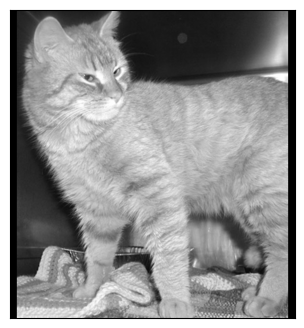

In [19]:
plot_img(x_test[x_test.shape[0]-1], im_shape=(540, 499))

In [23]:
inpx = Input(shape=(540, 499, 1))
x = Conv2D(16, (3,3), activation='relu', padding='same')(inpx)
x = MaxPooling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
out = Dense(1, activation='sigmoid')(x)

In [24]:
model = Model([inpx], out)
model.compile(optimizer=SGD(),
              loss=binary_crossentropy,
              metrics=['accuracy'])

In [25]:
model.fit(x_train, y_train, epochs=10)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 877ms/step - accuracy: 0.5659 - loss: 0.6842
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 863ms/step - accuracy: 0.6021 - loss: 0.6716
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 873ms/step - accuracy: 0.6021 - loss: 0.6692
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 832ms/step - accuracy: 0.6021 - loss: 0.6654
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 814ms/step - accuracy: 0.6021 - loss: 0.6657
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 823ms/step - accuracy: 0.6021 - loss: 0.6601
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 865ms/step - accuracy: 0.6021 - loss: 0.6567
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 846ms/step - accuracy: 0.6021 - loss: 0.6541
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 908ms/step - accuracy: 0.6150 - loss: 0.6539
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 864ms/step - accuracy: 0.6021 - loss: 0.6510


In [14]:
# checking test set performance
score = model.evaluate(x_test, y_6test, verbose=0)
print('loss=', score[0])
print('accuracy=', score[1])

loss= 0.01371559128165245
accuracy= 0.9955999851226807


In [15]:
# Seems good, but check HOW it's good
import pandas as pd

preds = model.predict(x_test)
y_true = np.asarray(y_6test).ravel().astype(int)
y_pred = (preds.reshape(-1) >= 0.5).astype(int)
tbl = pd.crosstab(y_pred, y_true, rownames=['Predicted'], colnames=['Actual'])
print(tbl)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Actual        0    1
Predicted           
0          9032   34
1            10  924


In [16]:
# print kernel weights of the convolutional layer
conv_weights = model.layers[1].get_weights()[0]
W = conv_weights[:,:,0,0]
print("Convolutional kernel weights:")
print(W)

Convolutional kernel weights:
[[-0.00999276  0.09565605 -0.02722668]
 [-0.33895501 -0.79619735 -1.0563811 ]
 [-0.37598798 -0.8659836  -1.2493305 ]]


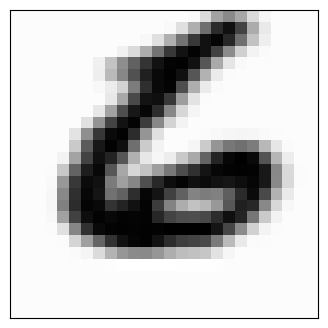

In [17]:
# grab the convMat function from cnn.ipynb to do the forward pass and then visualize what the recovered kernel is doing
def convMat(X, W):
    # get the dimensions of the kernel and input
    k, _ = W.shape
    p, _ = X.shape

    # calculate the dimensions of the output matrix
    q = p - k + 1
    G = np.zeros((q, q))

    # do the thing
    for m in range(q):
        for n in range(q):
            submatrix = X[m:m+k, n:n+k]
            G[m, n] = np.sum(W * submatrix)

    return G

G = convMat(x_test[x_test.shape[0]-1][:,:,0], W)

# image isn't changing a lot in the convolutional layer
plot_img(G, G.shape)